In [7]:
import pandas as pd
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "AMZN", "JPM", "GS"]
price_data = pd.DataFrame()

for ticker in tickers:
    df = pd.read_csv(f"../data/raw/{ticker}.csv", index_col = 0, parse_dates = True)
    price_data[ticker] = pd.to_numeric(df["Close"], errors='coerce')

price_data.head()


C:\Users\yogst\AppData\Local\Temp\ipykernel_15476\2179087806.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"../data/raw/{ticker}.csv", index_col = 0, parse_dates = True)
C:\Users\yogst\AppData\Local\Temp\ipykernel_15476\2179087806.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"../data/raw/{ticker}.csv", index_col = 0, parse_dates = True)
C:\Users\yogst\AppData\Local\Temp\ipykernel_15476\2179087806.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"../data/raw/{ticker}.csv", index_col = 0, parse_dates = True

,AAPL,MSFT,AMZN,JPM,GS
Price,,,,,
Ticker,NaN,NaN,NaN,NaN,NaN
Date,NaN,NaN,NaN,NaN,NaN
2020-01-02,72.468269,152.505676,94.900497,119.036400,203.182617
2020-01-03,71.763710,150.606705,93.748497,117.465569,200.806702
2020-01-06,72.335541,150.996033,95.143997,117.372185,202.861786


In [8]:
import numpy as np

returns = np.log(price_data).diff().dropna()
returns.head()

# This code converts prices into log prices (by applying natural log), computer the daily log returns, and removes the first Nan row (as it has nothing to subract from)


,AAPL,MSFT,AMZN,JPM,GS
Price,,,,,
2020-01-03,-0.009770,-0.012530,-0.012213,-0.013284,-0.011762
2020-01-06,0.007937,0.002582,0.014776,-0.000795,0.010182
2020-01-07,-0.004714,-0.009160,0.002089,-0.017147,0.006561
2020-01-08,0.015958,0.015803,-0.007839,0.007771,0.009593
2020-01-09,0.021018,0.012416,0.004788,0.003645,0.020152


          AAPL      MSFT      AMZN       JPM        GS
AAPL  1.000000  0.750913  0.594780  0.414321  0.467938
MSFT  0.750913  1.000000  0.680172  0.424329  0.473137
AMZN  0.594780  0.680172  1.000000  0.269223  0.353876
JPM   0.414321  0.424329  0.269223  1.000000  0.827982
GS    0.467938  0.473137  0.353876  0.827982  1.000000


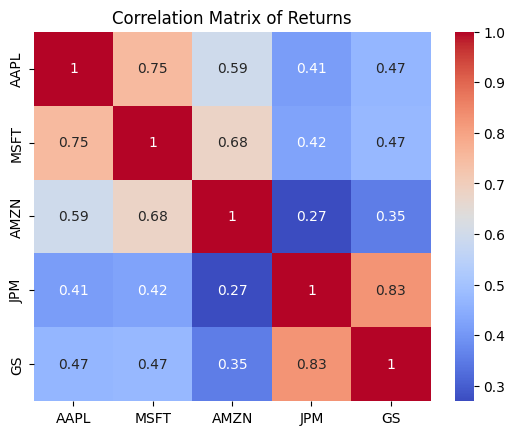

In [13]:
corr_matrix = returns.corr()
print(corr_matrix)

# Note : .corr() is a pandas method that gives the correlation between

import seaborn as sns
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm")
plt.title("Correlation Matrix of Returns")
plt.show()

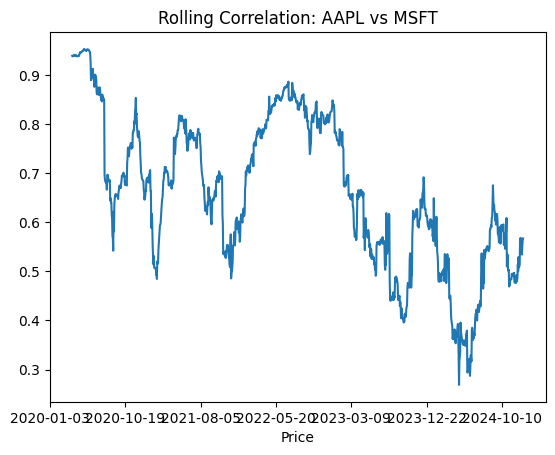

In [14]:
window = 60 # 60 trading days (~3 months)
rolling_corr = returns['AAPL'].rolling(window).corr(returns["MSFT"])

# Note: the line above essentiall creates a rolling window of 60, the .corr() calculates the Pearson correlation between the rolling window of AAPL and the entire series of MSFT returns.
# This helps us to soo the correlation between stocks that changes over time, and see how the relationship "evolves"

rolling_corr.plot(title = "Rolling Correlation: AAPL vs MSFT")
plt.show()

### Cointegration Concept

- Correlation(def) = short-term linear relationship between 2 series at the same point in time.
- Cointegration (def) = 2 series are cointegrated if a linear combination of them is stationary, even if the induvidual series are non-stationary (It tells us the 2 series can wander, but they don't drift too far apart in the long run.)
- Cointegration is more stable for statistical arbitrage as correlation can change a lot over time - it's a short term snapshot. Cointegration captures a long term relationship, which is more reliable. (Correlation: “Do two cars move in the same direction right now?” → can be misleading if they just happen to speed up together. Cointegration: “Are the two cars tied together by a rope?” → even if they speed up or slow down, they can’t drift too far apart.)